In [7]:
%load_ext autoreload
%autoreload 2
%time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 6.68 µs


In [8]:
import sys, os 
sys.path.append("../../")
from data_loading import load_runs

RUN = ["1"]  # this can be a list of several runs, i.e. [1,2,3]
blinded = True

#For 1mu1p
rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",  # which data to load
    # truth_filtered_sets=["nue", "drt", "nc_pi0", "cc_pi0", "cc_nopi", "cc_cpi", "nc_nopi", "nc_cpi"],
    # Which truth-filtered MC sets to load in addition to the main MC set. At least nu_e and dirt
    # are highly recommended because the statistics at the final level of the selection are very low.
    truth_filtered_sets=["nue", "drt"],
    # Choose which additional variables to load. Which ones are required may depend on the selection
    # you wish to apply.
    loadpi0variables=True,
    loadshowervariables=True,
    loadrecoveryvars=True,
    loadsystematics=True,
    loadnumuvariables=True, # True for 1mu1p/ False for 1e1p
    numupresel=False, # Set to False for full sample
    # Load the nu_e set one more time with the LEE weights applied
    load_lee=False,
    # With the cache enabled, by default the loaded dataframes will be stored as HDF5 files
    # in the 'cached_dataframes' folder. This will speed up subsequent loading of the same data.
    enable_cache=True,
    # Since this is Open Data, we are allowed to unblind the data. By default, the data is blinded.
    blinded=blinded,
    load_numu_tki=True,
    load_nue_tki=True
)


Loading run 1


KeyboardInterrupt: 

In [3]:
# norm_rundata_nue={}
# for k, df in rundata_nue.items():
#     print(k)
#     if k not in ["data", "ext"]:
#         norm_rundata_nue[k] = rundata_nue[k]
#         norm_rundata_nue[k]["weights"] = norm_rundata_nue[k]["weightSplineTimesTune"] * data_pot/mc_weights_nue[k]

In [4]:
print("trk_score_v" in rundata["mc"].columns)
#print("weightSplineTimesTune" in norm_rundata_nue["nue"].columns)
# print(norm_rundata_nue["nue"]["weights"])
rundata["mc"].loc[:, ("MuonCandidateIdx_1muNp", "backtracked_pdg")].head(20)

False


,MuonCandidateIdx_1muNp,backtracked_pdg
entry,,
0,-1,[]
1,-1,[]
2,-1,[]
3,0,"[13, 2212]"
4,0,"[13, 211]"
5,-1,[]
6,0,[13]
7,-1,[]
8,0,"[13, 0, 2212]"


#  SELECTIONS

In [5]:
from microfit import selections as sel
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Choose your selection and preselection category
## 1mu1p
selection_1mu1p   =  "TKI_1mu1p" #"SIGNAL_1MU1P"#"TKI_1mu1p" #"TKI_1mu1p" #"SG_1MU1P" 
preselection_1mu1p = "NUMU" #"SIGNAL_1MUNP"#"SG_1MUNP"NUMU

## 1e1p
selection_1e1p   = "TKI_1e1p" #"OneP_NPBDTXS"
preselection_1e1p = "NUE"

# Build the full query (e.g. sel_CCNp0pi and sel_CC1p0pi)
query_1mu1p = f"{sel.preselection_categories[preselection_1mu1p]['query']} and {sel.selection_categories[selection_1mu1p]['query']}"
sel_title_1mu1p = sel.selection_categories[selection_1mu1p]['title']

query_1e1p = f"{sel.preselection_categories[preselection_1e1p]['query']} and {sel.selection_categories[selection_1e1p]['query']}"
sel_title_1e1p = sel.selection_categories[selection_1e1p]['title']

#print(type(query_1e1p))
all_mc      = pd.concat([df for k, df in rundata.items() if k not in ['data', 'ext']])

sel_mc_1mu1p    = all_mc.query(query_1mu1p, engine='python')
sel_mc_1e1p     = all_mc.query(query_1e1p, engine='python')


## GKI variables: pN 

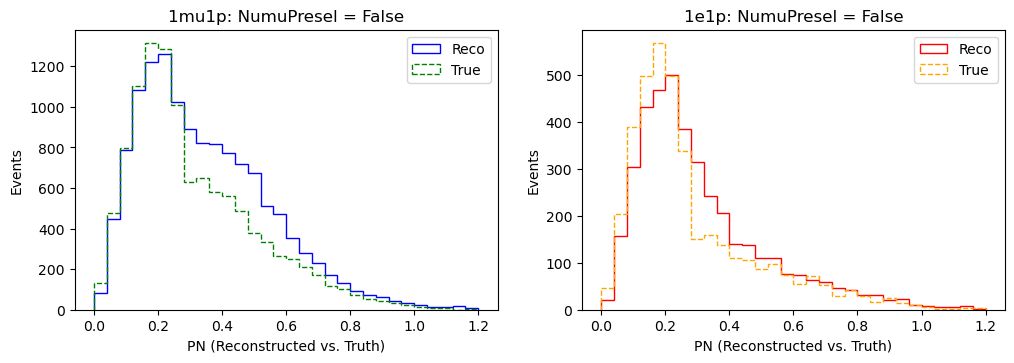

In [6]:
# Plot TKI variable distributions for selected 1mu1p events (Reconstructed vs. Truth)

plt.figure(figsize=(12, 8))

# Plot RecoDeltaPT_1mu1p vs TrueDeltaPT_1mu1p
plt.subplot(2, 2, 1)
plt.hist(sel_mc_1mu1p['RecoPN_1mu1p'], bins=30, range=(0, 1.2), histtype='step', linestyle='-', color='blue', label='Reco')
plt.hist(sel_mc_1mu1p['TruePN_1mu1p'], bins=30, range=(0, 1.2), histtype='step', linestyle='--', color='green', label='True')
plt.xlabel('PN (Reconstructed vs. Truth)')
plt.ylabel('Events')
plt.title('1mu1p: NumuPresel = False')
plt.legend()


plt.subplot(2, 2, 2)
plt.hist(sel_mc_1e1p['RecoPN'], bins=30, range=(0, 1.2), histtype='step', linestyle='-', color='red', label='Reco')
plt.hist(sel_mc_1e1p['TruePN'], bins=30, range=(0, 1.2), histtype='step', linestyle='--', color='orange', label='True')
plt.xlabel('PN (Reconstructed vs. Truth)')
plt.ylabel('Events')
plt.title('1e1p: NumuPresel = False')
plt.legend()


In [23]:
# # Plot TKI variable distributions for selected 1mu1p events (Reconstructed vs. Truth)

# plt.figure(figsize=(12, 8))

# # Plot RecoDeltaPT_1mu1p vs TrueDeltaPT_1mu1p
# plt.subplot(2, 2, 1)
# plt.hist(sel_mc_1e1p_numu['RecoPN'], bins=30, range=(0, 1.2), histtype='step', linestyle='-', color='red', label='Reco')
# plt.hist(sel_mc_1e1p_numu['TruePN'], bins=30, range=(0, 1.2), histtype='step', linestyle='--', color='orange', label='True')
# plt.xlabel('PN (Reconstructed vs. Truth)')
# plt.ylabel('Events')
# plt.title('1e1p: numuPresel=True')
# plt.legend()

# # Plot RecoPN_1e1p vs TruePN_1mu1p
# plt.subplot(2, 2, 2)
# plt.hist(sel_mc_1e1p['RecoPN'], bins=30, range=(0, 1.2), histtype='step', linestyle='-', color='red', label='Reco')
# plt.hist(sel_mc_1e1p['TruePN'], bins=30, range=(0, 1.2), histtype='step', linestyle='--', color='orange', label='True')
# plt.xlabel('PN (Reconstructed vs. Truth)')
# plt.ylabel('Events')
# plt.title('1e1p: numuPresel=False')
# plt.legend()

# plt.subplot(2, 2, 3)
# plt.hist(sel_mc_1e1p_numu['RecoPN'], bins=30, range=(0, 1.2), histtype='step', linestyle='-', color='red', label='Reco-numuPresel=True')
# plt.hist(sel_mc_1e1p['RecoPN'], bins=30, range=(0, 1.2), histtype='step', linestyle='--', color='red', label='Reco-numuPresel=False')
# plt.xlabel('1e1p: PN (GeV)')
# plt.ylabel('Events')
# #plt.title('1e1p: numuPresel=False')
# plt.legend()


# Ecal Resolution

/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

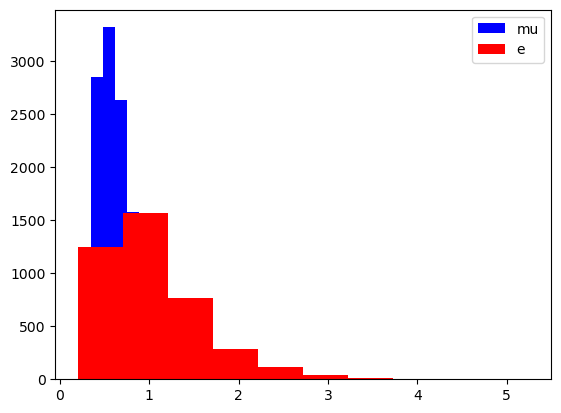

In [24]:
# Binding energy (GeV)
binding_energy = 0.02478 #0.03
proton_mass    = 0.9382720813


# Extract all true and reco energies (no interaction cut)
true_muon_energy        = sel_mc_1mu1p["TrueMuonE_1muNp"].values
true_lead_proton_energy = sel_mc_1mu1p["TrueLeadProtonE_1muNp"].values
reco_muon_energy        = sel_mc_1mu1p["RecoMuonE_1muNp"].values
reco_lead_proton_energy = sel_mc_1mu1p["RecoLeadProtonE_1muNp"].values

true_elec_energy         = sel_mc_1e1p["TrueElecE_1e1p"].values
true_lead_eproton_energy = sel_mc_1e1p["TrueLeadProtonE_1e1p"].values
reco_elec_energy         = sel_mc_1e1p["RecoElecE"].values
reco_lead_eproton_energy = sel_mc_1e1p["RecoLeadProtonE"].values


# Compute reco neutrino energy via Ecal method
reco_proton_ke     = reco_lead_proton_energy - proton_mass
reco_ecal_energy   = reco_muon_energy + reco_proton_ke + binding_energy
true_nu_energy     = sel_mc_1mu1p["nu_e"].values

reco_eproton_ke      = reco_lead_eproton_energy - proton_mass
reco_eecal_energy    = reco_elec_energy + reco_eproton_ke + binding_energy
true_enu_energy      = sel_mc_1e1p["nu_e"].values

# plt.hist(reco_eecal_energy,label='e')
# plt.hist(reco_ecal_energy,label='mu')

# plt.hist(true_nu_energy,label='mu', color='blue')
# plt.hist(true_enu_energy,label='e', color='red')
plt.hist(reco_ecal_energy,label='mu', color='blue')
plt.hist(reco_eecal_energy,label='e', color='red')



plt.legend()
# Compute Ecal resolution
ecal_resolution_1mu1p = (reco_ecal_energy - true_nu_energy) / true_nu_energy
ecal_resolution_1e1p  = (reco_eecal_energy - true_enu_energy) / true_enu_energy
#print(len(ecal_resolution_1e1p))

# Add to DataFrame
sel_mc_1mu1p['Ecal_1mu1p'] = ecal_resolution_1mu1p
sel_mc_1mu1p['E_Reco'] = reco_ecal_energy
sel_mc_1mu1p['E_True'] = true_nu_energy

sel_mc_1e1p['Ecal_1e1p'] = ecal_resolution_1e1p
sel_mc_1e1p['E_eReco'] = reco_eecal_energy
sel_mc_1e1p['E_eTrue'] = true_enu_energy

# Plotting
# plt.figure(figsize=(12, 8))

#Resolution histogram
# plt.subplot(2, 2, 1)
# plt.hist(sel_mc_1mu1p['Ecal_1mu1p'], bins=20, range=(-1, 1),
#          histtype='step', linestyle='-', color='Green', label='1mu1p')
# plt.xlabel('Ecal Resolution')
# plt.ylabel('Events')
# plt.title('Ecal Resolution Distribution for 1mu1p Events')# (All Interaction Types)')
# plt.legend()

# plt.subplot(2, 2, 2)
# plt.hist(sel_mc_1e1p['Ecal_1e1p'], bins=20, range=(-1, 1),
#          histtype='step', linestyle='-', color='Red', label='1e1p')
# plt.xlabel('Ecal Resolution')
# plt.ylabel('Events')
# plt.title('Ecal Resolution Distribution for 1e1p Events')# (All Interaction Types)')
# plt.legend()

# plt.tight_layout()
# plt.show()


# Ecal Plots

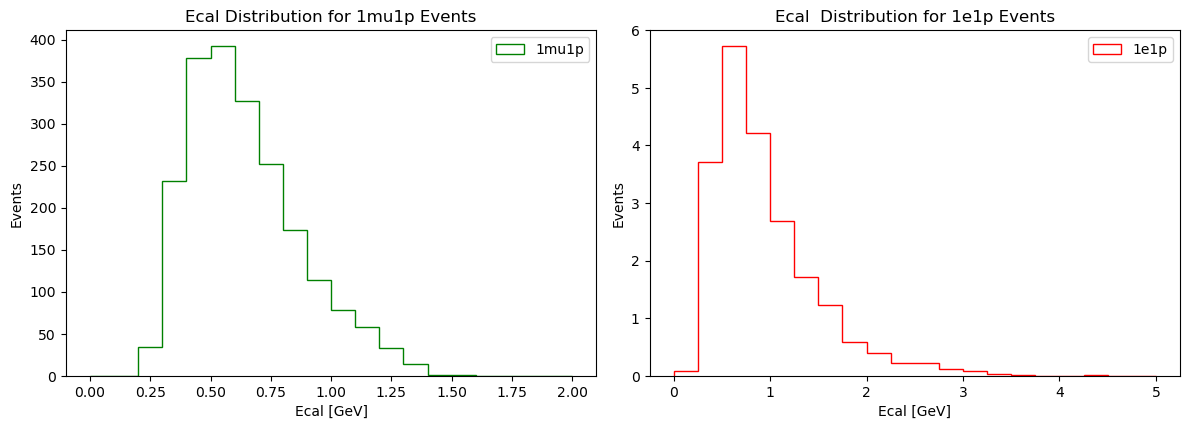

In [39]:
# Todo: Normalize it to POT

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(sel_mc_1mu1p['E_Reco'], bins=20, weights=sel_mc_1mu1p['weights'], range=(0, 2),
         histtype='step', linestyle='-', color='Green', label='1mu1p')
plt.xlabel('Ecal [GeV]')
plt.ylabel('Events')
plt.title('Ecal Distribution for 1mu1p Events')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(sel_mc_1e1p['E_eReco'], bins=20, weights=sel_mc_1e1p['weights'], range=(0, 5),
         histtype='step', linestyle='-', color='Red', label='1e1p')
plt.xlabel('Ecal [GeV]')
plt.ylabel('Events')
plt.title('Ecal  Distribution for 1e1p Events')
plt.legend()

plt.tight_layout()
plt.show()


In [26]:
# # Adding to DataFrame Locally
#1mu1p
for k, df in rundata.items():
    if df is None:
        continue
    #Ecal for all events
    df["RecoEcal_1mu1p_all"] = (
        df["RecoMuonE_1muNp"] + (df["RecoLeadProtonE_1muNp"] - proton_mass) + binding_energy
    )
#1e1p
    df["RecoEcal_1e1p_all"] = (
    df["RecoElecE"] + (df["RecoLeadProtonE"] - proton_mass) + binding_energy # This is not saving to rundata
    #rundata[k]["RecoEcal_1e1p_all"] = (
    #    df["RecoElecE"] + (df["RecoLeadProtonE"] - proton_mass) + binding_energy
    )
    df['trkpid'] = df['trkpid'].dropna()
    
# for k, df in rundata.items():
#     if df is None or 'trkpid' not in df.columns:
#         continue
#     df['trkpid'] = pd.to_numeric(df['trkpid'], errors='coerce') \
#                       .replace([np.inf, -np.inf], np.nan)
#     df.dropna(subset=['trkpid'], inplace=True)   # removes rows with NaN trkpid     

In [27]:
print(df["trkpid"])

entry
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
102146   NaN
102147   NaN
102148   NaN
102149   NaN
102150   NaN
Name: trkpid, Length: 102151, dtype: float64


In [28]:
from microfit.histogram import Binning, Histogram, RunHistGenerator, MultiChannelBinning

# Binnings are defined by the variable to be binned, the number of bins, and the range, and the label.
binning_1mu1p = ("trkpid", 20, (-1.0, 1.0), r"1mu1p trk pid") # for checking pdg
#binning_1mu1p = ("RecoEcal_1mu1p_all", 20, (0.0, 2.0), r"1mu1p Ecal(GeV)")
binning_1mu1p = Binning.from_config(*binning_1mu1p)
binning_1mu1p.label = "1mu1p"  # a unique label to identify the channel later
binning_1mu1p.set_selection(selection_1mu1p, preselection_1mu1p)
# The binning is a class with a defined repr:


#1e1p
binning_1e1p = ("RecoEcal_1e1p_all", 20, (0.0, 2.0), r"1e1p Ecal(GeV)")
#binning_1e1p = ("RecoPN", None, None, "$p_n$ [GeV/c]", False, None, [0,0.3,1.7]) #Maitreyee's binning

binning_1e1p = Binning.from_config(*binning_1e1p)
binning_1e1p.label = "1e1p"  # a unique label to identify the channel later
binning_1e1p.set_selection(selection_1e1p, preselection_1e1p)

#binning_1e1p
binning_1mu1p

Binning(variable='trkpid', bin_edges=array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
        0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ]), label='1mu1p', variable_tex='1mu1p trk pid', variable_tex_short=None, is_log=False, selection_query='nslice == 1 and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1) and reco_nu_vtx_sce_x > 5 and reco_nu_vtx_sce_x < 251.  and reco_nu_vtx_sce_y > -110 and reco_nu_vtx_sce_y < 110.  and reco_nu_vtx_sce_z > 20 and reco_nu_vtx_sce_z < 986.  and (reco_nu_vtx_sce_z < 675 or reco_nu_vtx_sce_z > 775)  and topological_score > 0.06  and sel_CC1p0pi == True', selection_key='TKI_1mu1p', preselection_key='NUMU', selection_tex='1mu1p Selection', selection_tex_short='1mu1p Selection')

In [29]:
print("RecoEcal_1mu1p_all" in rundata["mc"].columns)


True


## Plotting 

In [30]:
signal_generator_1mu1p = RunHistGenerator(
    rundata,
    binning_1mu1p,
    data_pot=data_pot,
    # selection=selection,
    # preselection=preselection,
)
signal_generator_1e1p = RunHistGenerator(
    rundata,
    binning_1e1p,
    data_pot=data_pot,
    # selection=selection,
    # preselection=preselection,
)

total_prediction_1mu1p = signal_generator_1mu1p.get_total_prediction(include_multisim_errors=True)
total_prediction_1e1p  = signal_generator_1e1p.get_total_prediction(include_multisim_errors=True)

#total_prediction_1mu1p


In [31]:
from microfit.run_plotter import RunHistPlotter

plotter = RunHistPlotter(signal_generator_1mu1p)
# The category column can be used to split the prediction into different categories.
# Predefined categories are "category", "paper_category", "paper_category_xsec" and "category_1e1p".
# New categories can be added by adding a corresponding column to the dataframe and then define
# the labels in the file `category_definitions.py`.
ax = plotter.plot(
    category_column="trk_pdg",#"category_1mu1p", #trk_pdg 
    include_multisim_errors=True,
    add_ext_error_floor=False,
    show_data_mc_ratio=False,
    show_chi_square=False,
)

ax = plotter.plot(
    category_column="interaction",
    include_multisim_errors=True,
    add_ext_error_floor=False,
    show_data_mc_ratio=False,
    show_chi_square=False,
)

KeyError: nan

In [ ]:
plotter = RunHistPlotter(signal_generator_1e1p)
# The category column can be used to split the prediction into different categories.
# Predefined categories are "category", "paper_category", "paper_category_xsec" and "category_1e1p".
# New categories can be added by adding a corresponding column to the dataframe and then define
# the labels in the file `category_definitions.py`.
ax = plotter.plot(
    category_column="category_1e1p",
    include_multisim_errors=True,
    add_ext_error_floor=False,
    show_data_mc_ratio=False,
    show_chi_square=False,
)

ax = plotter.plot(
    category_column="interaction",
    include_multisim_errors=True,
    add_ext_error_floor=False,
    show_data_mc_ratio=False,
    show_chi_square=False,
)

### pN cuts in Ecal

In [51]:
# # # Adding to DataFrame Locally
# for k, df in rundata.items():
#     if df is None:
#         continue
#     #Ecal for all events
#     df["RecoEcal_1mu1p_pN"] = (
#         df["RecoMuonE_1muNp"] + (df["RecoLeadProtonE_1muNp"] - proton_mass) + binding_energy
#     )
#     df["RecoEcal_1e1p_all"] = (
#         df["RecoElecE"] + (df["RecoLeadProtonE"] - proton_mass) + binding_energy
#     )
#     # ECal only for pN<0.4
#     mask = df["RecoDeltaPT_1mu1p"] < 0.4
#     df["RecoECal_1mu1p_pT04"] = np.nan
#     df.loc[mask, "RecoECal_1mu1p_pT04"] = df.loc[mask, "RecoECal_1mu1p_all"]
    
#         # ECal only for pN<0.3
#     mask = df["RecoDeltaPT_1mu1p"] < 0.3
#     df["RecoECal_1mu1p_pT03"] = np.nan
#     df.loc[mask, "RecoECal_1mu1p_pT03"] = df.loc[mask, "RecoECal_1mu1p_all"]
    
#         # ECal only for pN<0.2
#     mask = df["RecoDeltaPT_1mu1p"] < 0.2
#     df["RecoECal_1mu1p_pT02"] = np.nan
#     df.loc[mask, "RecoECal_1mu1p_pT02"] = df.loc[mask, "RecoECal_1mu1p_all"]
    
    

## ECAL in PN slices (Interactions)

## 1mu1p

In [52]:
slices_pn_1mu1p = [
    '0 < RecoPN_1mu1p < 0.1',
    '0.1 < RecoPN_1mu1p < 0.2',
    '0.2 < RecoPN_1mu1p < 0.3',
    '0.3 < RecoPN_1mu1p < 0.4',
    '0.4 < RecoPN_1mu1p < 0.5',
    '0.5 < RecoPN_1mu1p < 0.6',
    '0.6 < RecoPN_1mu1p < 0.7',
    '0.7 < RecoPN_1mu1p < 0.8',
    '0.8 < RecoPN_1mu1p < 1.2',
    '0.0 < RecoPN_1mu1p < 0.3',
]
print("Min and Max of RecoPN_1mu1p:", sel_mc_1mu1p['RecoPN_1mu1p'].min(), sel_mc_1mu1p['RecoPN_1mu1p'].max())


Min and Max of RecoPN_1mu1p: 0.007767703745632782 2.1008349697684907


data
data
ext
mc
nue
drt


../../microfit/histogram/run_hist_generator.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["dataset_name"] = k
../../microfit/histogram/run_hist_generator.py:164: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["dataset_name"] = df["dataset_name"].astype("category")


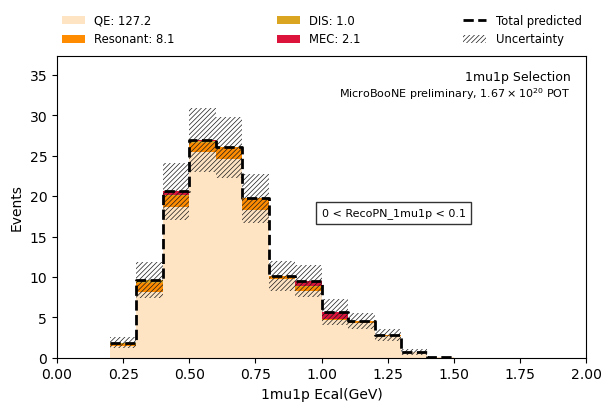

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

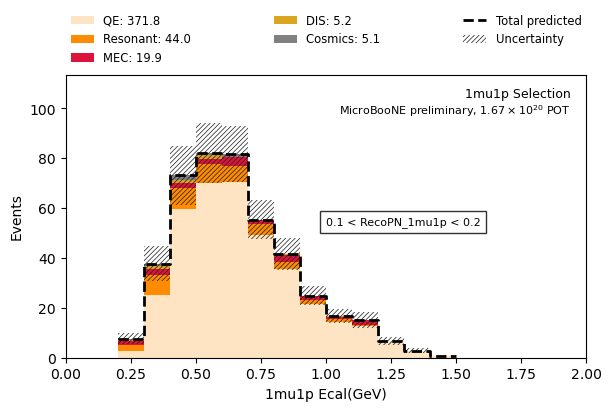

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

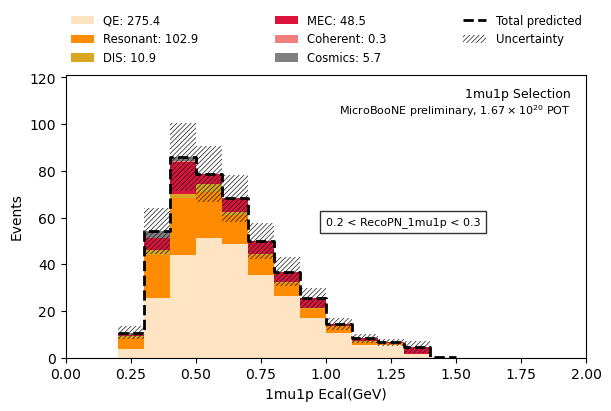

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

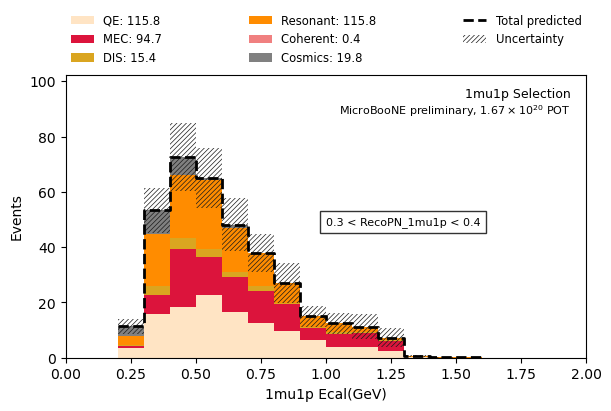

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

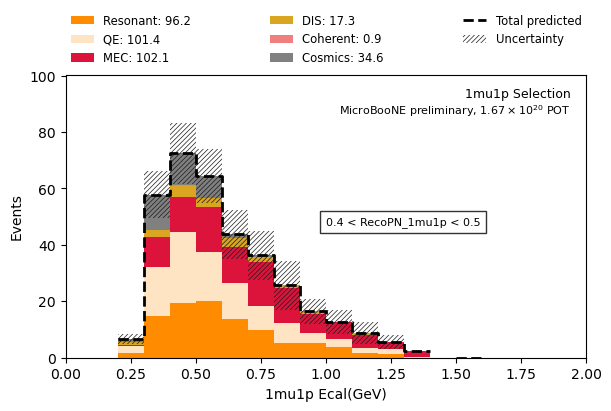

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

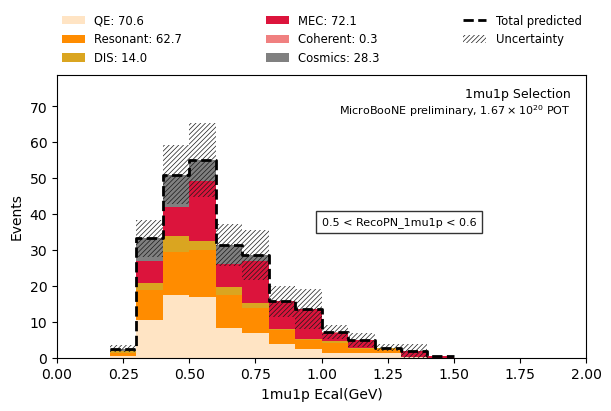

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

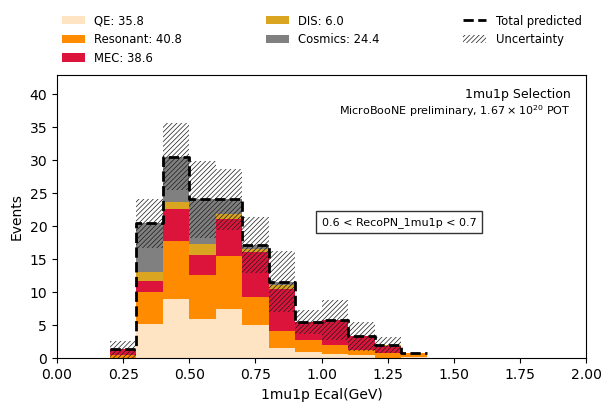

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

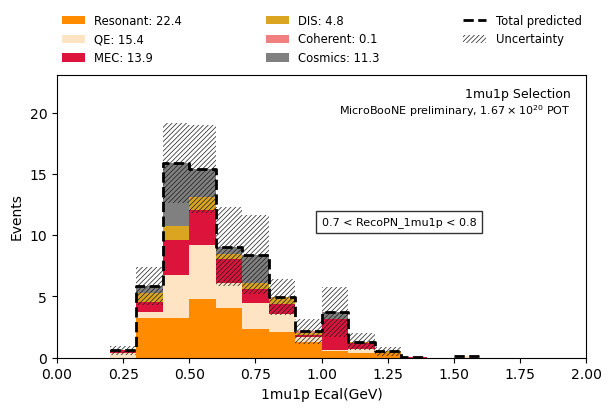

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

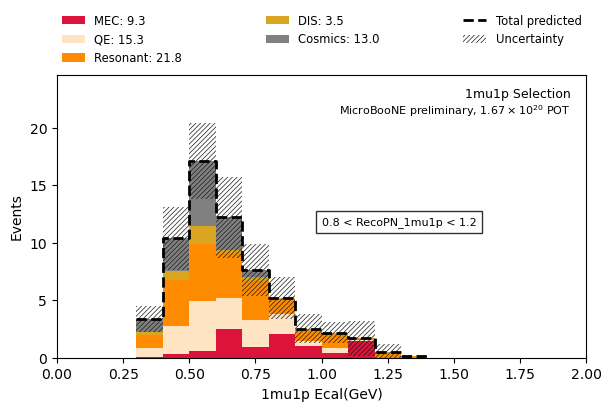

data
data
ext
mc
nue
drt


<Figure size 640x480 with 0 Axes>

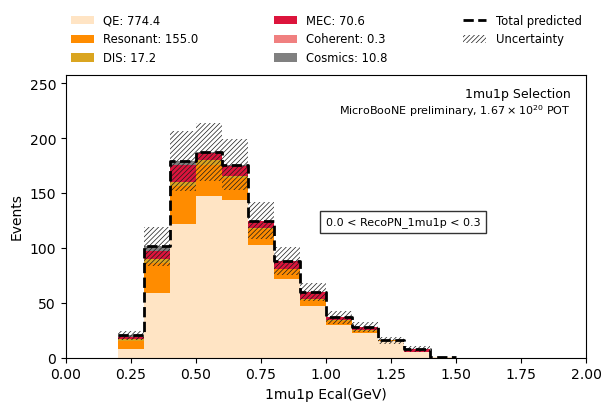

<Figure size 640x480 with 0 Axes>

In [53]:
from microfit import histogram as hist
from microfit import run_plotter as rp

#1mu1p
selection   ="TKI_1mu1p"
preselection="SG_1MUNP"
binning_1mu1p = ("RecoEcal_1mu1p_all", 20, (0.0, 2.0), r"1mu1p Ecal(GeV)")
binning_1mu1p = Binning.from_config(*binning_1mu1p)

for query in slices_pn_1mu1p:
    filtered_rundata = {}  
    for key, df in rundata.items():
        print(key)
        if rundata[key] is None:
            print(key)
            filtered_rundata[key] = None
        elif key in ["data"] and blinded:
            filtered_rundata["data"] = None
        else:
            filtered_rundata[key] = df.query(query, engine='python')
    
    signal_generator = hist.RunHistGenerator(
            filtered_rundata,
            binning_1mu1p.copy(),
            data_pot=data_pot,
            selection=selection,
            preselection=preselection,
            sideband_generator=None,
            uncertainty_defaults=None,
            detvar_data=None,
        )
    plotter = rp.RunHistPlotter(signal_generator)
    axes = plotter.plot(
            category_column="interaction",
            include_multisim_errors=True,
            add_ext_error_floor=False,
            show_data_mc_ratio=False,
            show_chi_square=False,
            show_total_unconstrained=False,
            add_precomputed_detsys=False,
            show_errorband=True,
        )
    
    ax = axes[0]
    ax.text(0.5, 0.5, query ,
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(facecolor='white', alpha=0.8), fontsize=8)


        #plt.savefig(f'analysis_plots/unfolding_inputs/int_sig_{preselection}_{selection}_{binning_def[0]}_{data}_{run_combo}_{binning_def[1]}bins.pdf', bbox_inches='tight')
        #plt.savefig(f'analysis_plots/unfolding_inputs/int_sig_{preselection}_{selection}_{binning_def[0]}_{data}_{run_combo}_{binning_def[1]}bins.png', bbox_inches='tight')
    plt.show()
    plt.clf()

## 1e1p

In [54]:
slices_pn_1e1p = [
    '0 < RecoPN < 0.1',
    '0.1 < RecoPN < 0.2',
    '0.2 < RecoPN < 0.3',
    '0.3 < RecoPN < 0.4',
    '0.4 < RecoPN < 0.5',
    '0.5 < RecoPN < 0.6',
    '0.6 < RecoPN < 0.7',
    '0.7 < RecoPN < 0.8',
    '0.8 < RecoPN < 0.9',
    '0.9 < RecoPN < 1.0',
    '1.0 < RecoPN < 1.2',
    '1.2 < RecoPN < 1.4',
    '0.0 < RecoPN < 0.3',
]
print("Min and Max of RecoPN_1e1p:", sel_mc_1e1p['RecoPN'].min(), sel_mc_1e1p['RecoPN'].max())


Min and Max of RecoPN_1e1p: 0.013699613096964793 1.400831614709331


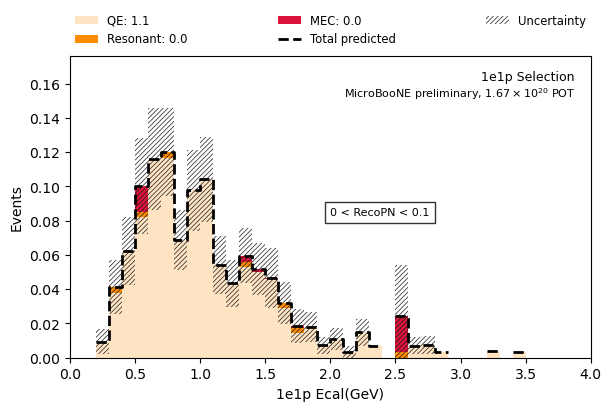

<Figure size 640x480 with 0 Axes>

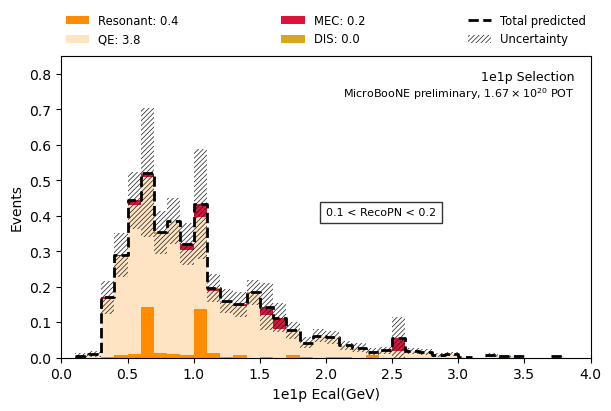

<Figure size 640x480 with 0 Axes>

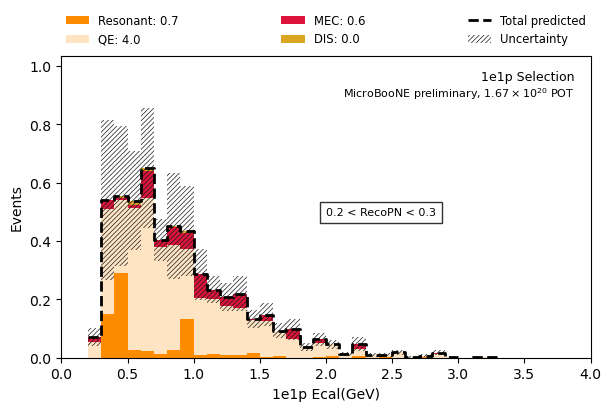

<Figure size 640x480 with 0 Axes>

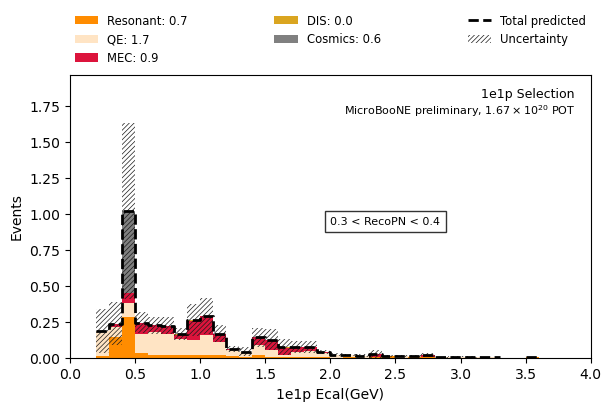

<Figure size 640x480 with 0 Axes>

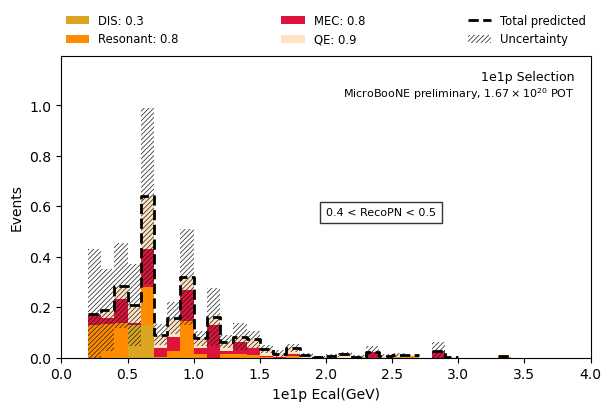

<Figure size 640x480 with 0 Axes>

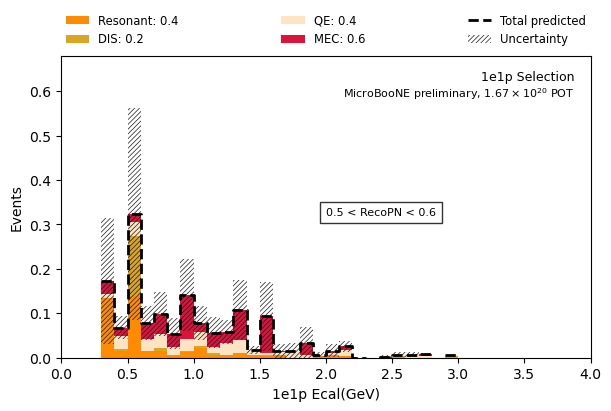

<Figure size 640x480 with 0 Axes>

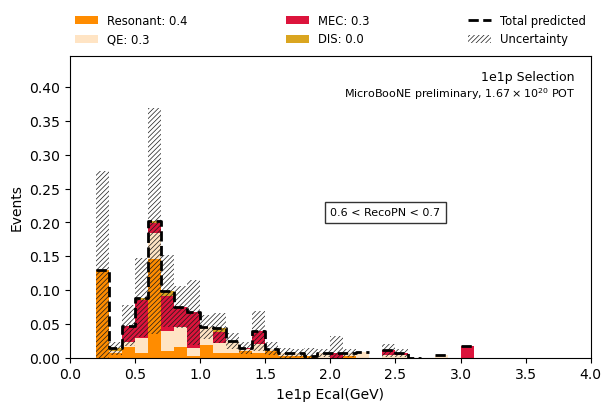

<Figure size 640x480 with 0 Axes>

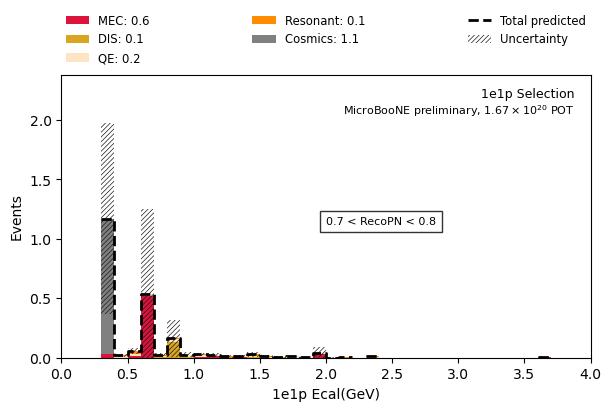

<Figure size 640x480 with 0 Axes>

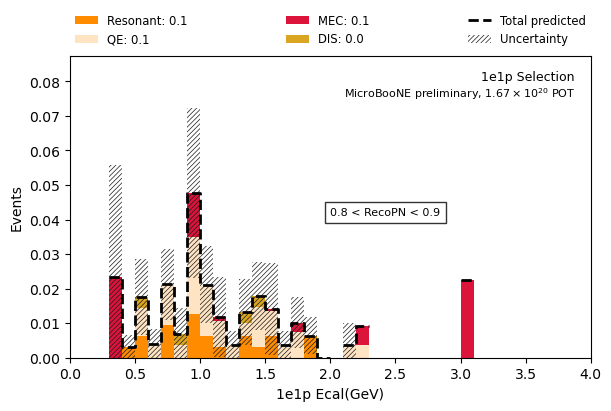

<Figure size 640x480 with 0 Axes>

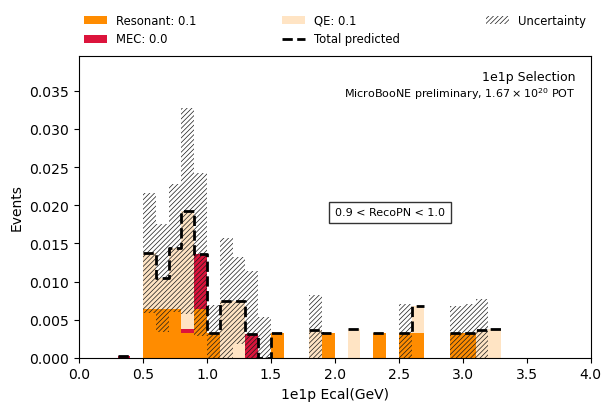

<Figure size 640x480 with 0 Axes>

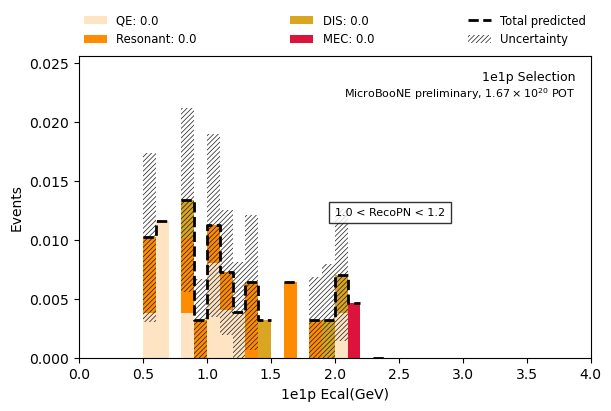

<Figure size 640x480 with 0 Axes>

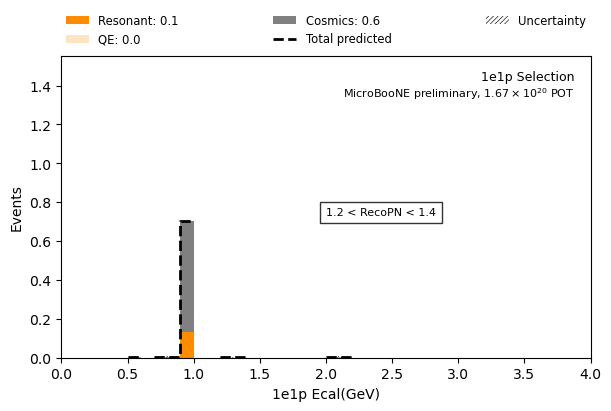

<Figure size 640x480 with 0 Axes>

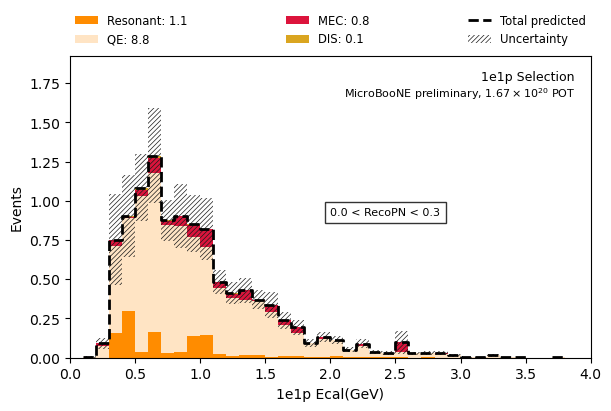

<Figure size 640x480 with 0 Axes>

In [55]:
from microfit import histogram as hist
from microfit import run_plotter as rp

#1e1p
selection   ="TKI_1e1p"
preselection="OneP"
binning_1e1p = ("RecoEcal_1e1p_all", 40, (0.0, 4.0), r"1e1p Ecal(GeV)")
binning_1e1p = Binning.from_config(*binning_1e1p)

for query in slices_pn_1e1p:
    filtered_rundata = {}  
    for key, df in rundata.items():
        #print(key)
        if rundata[key] is None:
            #print(key)
            filtered_rundata[key] = None
        elif key in ["data"] and blinded:
            filtered_rundata["data"] = None
        else:
            filtered_rundata[key] = df.query(query, engine='python')
    
    signal_generator = hist.RunHistGenerator(
            filtered_rundata,
            binning_1e1p.copy(),
            data_pot=data_pot,
            selection=selection,
            preselection=preselection,
            sideband_generator=None,
            uncertainty_defaults=None,
            detvar_data=None,
        )
    plotter = rp.RunHistPlotter(signal_generator)
    axes = plotter.plot(
            category_column="interaction",
            include_multisim_errors=True,
            add_ext_error_floor=False,
            show_data_mc_ratio=False,
            show_chi_square=False,
            show_total_unconstrained=False,
            add_precomputed_detsys=False,
            show_errorband=True,
        )
    
    ax = axes[0]
    ax.text(0.5, 0.5, query ,
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(facecolor='white', alpha=0.8), fontsize=8)


        #plt.savefig(f'analysis_plots/unfolding_inputs/int_sig_{preselection}_{selection}_{binning_def[0]}_{data}_{run_combo}_{binning_def[1]}bins.pdf', bbox_inches='tight')
        #plt.savefig(f'analysis_plots/unfolding_inputs/int_sig_{preselection}_{selection}_{binning_def[0]}_{data}_{run_combo}_{binning_def[1]}bins.png', bbox_inches='tight')
    plt.show()
    plt.clf()

# Ecal in pN slices

## 1mu1p

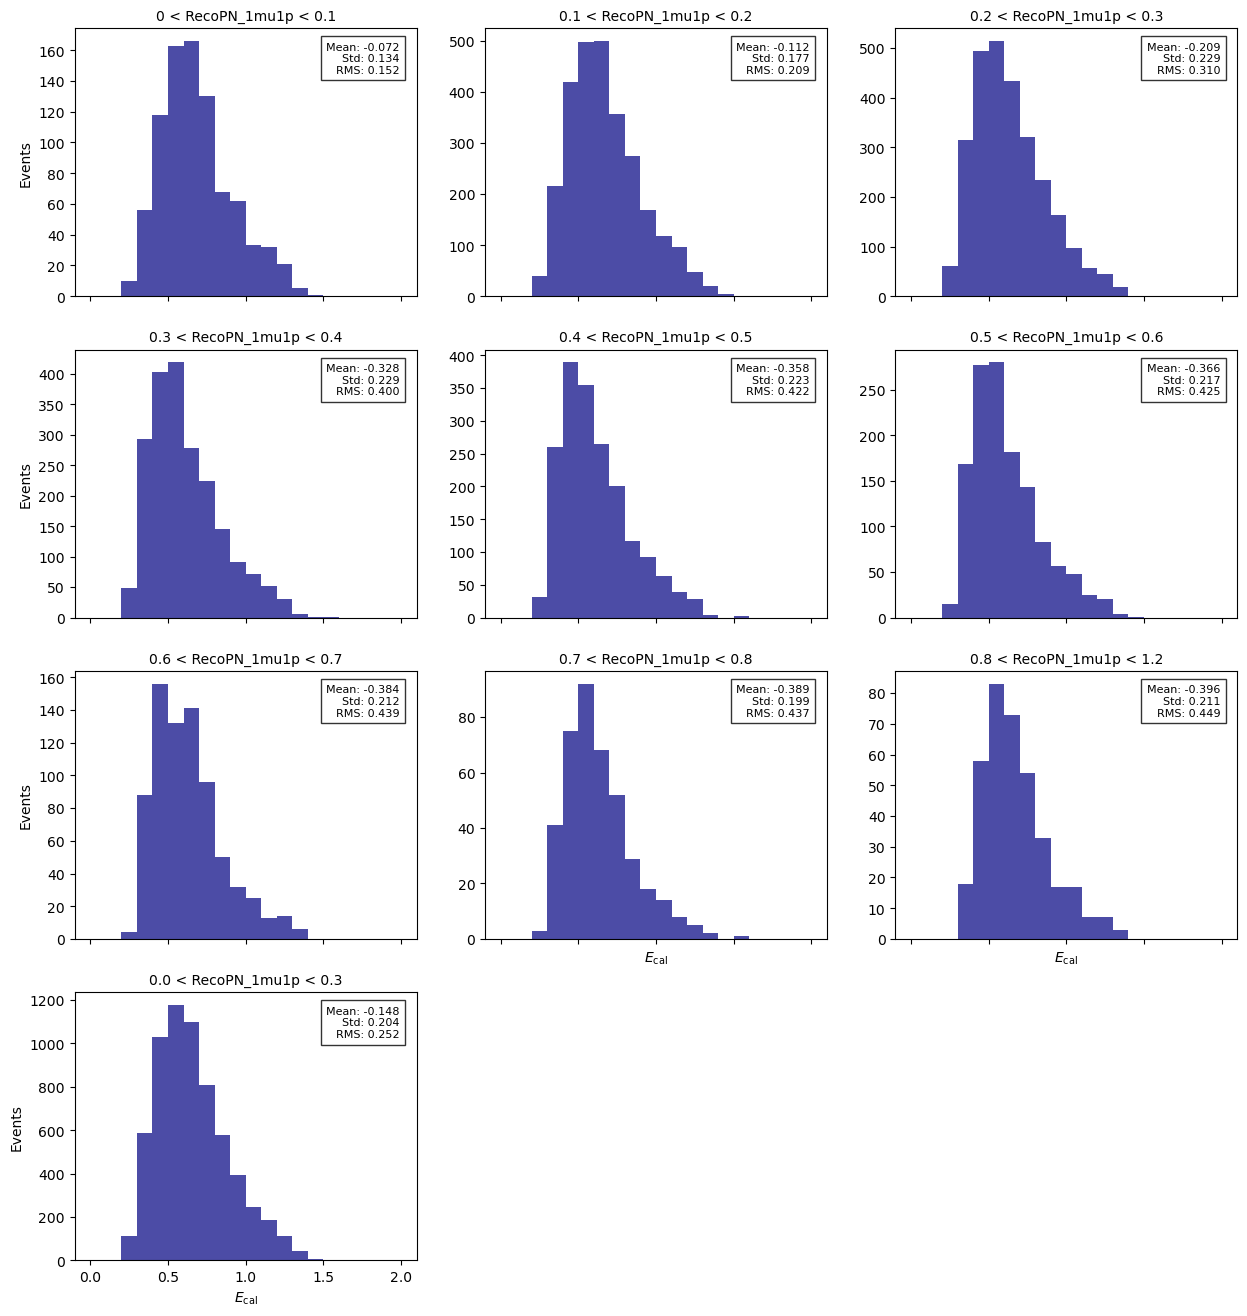

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Setup subplot grid
num_slices = len(slices_pn_1mu1p)
ncols = 3  # number of columns per row
nrows = int(np.ceil(num_slices / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=False)
axes = axes.flatten()  # Flatten in case of 2D layout

# Stats storage
ecal_rms_list = []
ecal_mean_list = []
ecal_std_list = []
slice_labels = []

for idx, s in enumerate(slices_pn_1mu1p):
    df = sel_mc_1mu1p.query(s, engine='python')

    reco_muon_energy = df["RecoMuonE_1muNp"]
    reco_proton_energy = df["RecoLeadProtonE_1muNp"]
    true_muon_energy = df["TrueMuonE_1muNp"]
    true_proton_energy = df["TrueLeadProtonE_1muNp"]
    
    reco_ecal = reco_muon_energy + (reco_proton_energy - proton_mass) + binding_energy
    true_ecal = df["nu_e"]
    resolution = (reco_ecal - true_ecal) / true_ecal

    # Stats
    mean = np.mean(resolution)
    std = np.std(resolution)
    rms = np.sqrt(np.mean(resolution ** 2))

    ecal_mean_list.append(mean)
    ecal_std_list.append(std)
    ecal_rms_list.append(rms)
    slice_labels.append(s.split('<')[-1].strip())

    # Plot in current subplot
    ax = axes[idx]
    ax.hist(reco_ecal, bins=20, range=(0.0, 2.0), histtype='stepfilled', color='navy', alpha=0.7)
    ax.set_title(f"{s}", fontsize=10)
    ax.text(0.95, 0.95, f"Mean: {mean:.3f}\nStd: {std:.3f}\nRMS: {rms:.3f}",
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8), fontsize=8)

    if idx % ncols == 0:
        ax.set_ylabel("Events")
    if idx >= num_slices - ncols:
        ax.set_xlabel("$E_\\mathrm{cal}$")

# Hide empty subplots (if any)
for j in range(len(slices_pn_1mu1p), len(axes)):
    fig.delaxes(axes[j])

# # Supertitle and layout
# fig.suptitle(f"Ecal Resolution in phiT Slices: {sel.selection_categories[selection]['title']}", fontsize=14)
# fig.tight_layout(rect=[0, 0, 1, 0.95])

# # Save single multi-panel figure
# plt.savefig(f'analysis_1mu1p/analysis_plots/resolution/ecal_resolution_grid_phiT_{preselection}_{selection}.pdf')
plt.show()


# 1e1p

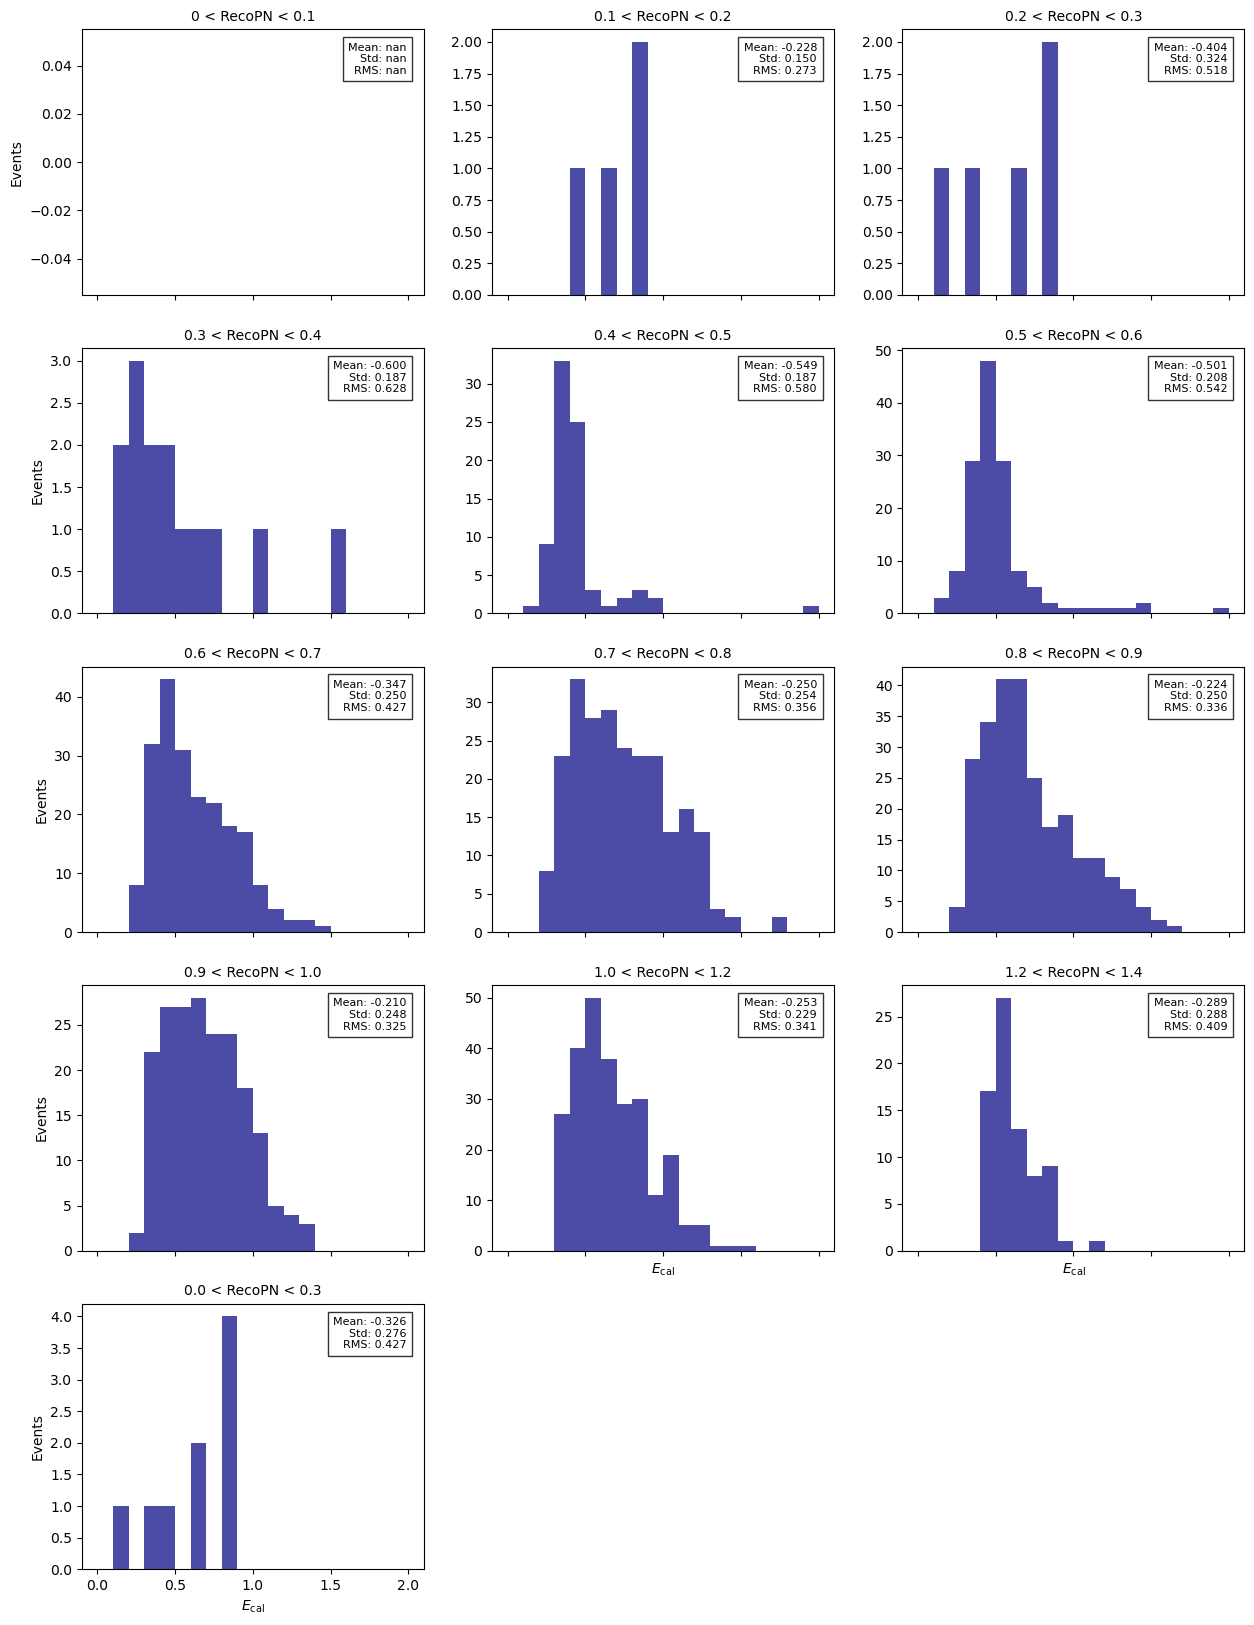

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Setup subplot grid
num_slices = len(slices_pn_1e1p)
ncols = 3  # number of columns per row
nrows = int(np.ceil(num_slices / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=False)
axes = axes.flatten()  # Flatten in case of 2D layout

# Stats storage
ecal_rms_list = []
ecal_mean_list = []
ecal_std_list = []
slice_labels = []

for idx, s in enumerate(slices_pn_1e1p):
    df = sel_mc_1mu1p.query(s, engine='python')

    reco_elec_energy = df["RecoElecE"]
    reco_proton_energy = df["RecoLeadProtonE"]
    true_elec_energy = df["TrueElecE_1e1p"]
    true_proton_energy = df["TrueLeadProtonE_1e1p"]
    
    reco_ecal = reco_elec_energy + (reco_proton_energy - proton_mass) + binding_energy
    true_ecal = df["nu_e"]
    resolution = (reco_ecal - true_ecal) / true_ecal

    # Stats
    mean = np.mean(resolution)
    std = np.std(resolution)
    rms = np.sqrt(np.mean(resolution ** 2))

    ecal_mean_list.append(mean)
    ecal_std_list.append(std)
    ecal_rms_list.append(rms)
    slice_labels.append(s.split('<')[-1].strip())

    # Plot in current subplot
    ax = axes[idx]
    ax.hist(reco_ecal, bins=20, range=(0.0, 2.0), histtype='stepfilled', color='navy', alpha=0.7)
    ax.set_title(f"{s}", fontsize=10)
    ax.text(0.95, 0.95, f"Mean: {mean:.3f}\nStd: {std:.3f}\nRMS: {rms:.3f}",
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8), fontsize=8)

    if idx % ncols == 0:
        ax.set_ylabel("Events")
    if idx >= num_slices - ncols:
        ax.set_xlabel("$E_\\mathrm{cal}$")

# Hide empty subplots 
for j in range(len(slices_pn_1e1p), len(axes)):
    fig.delaxes(axes[j])

plt.show()


All 1mu1p events
  Events: 13149
  Mean: -0.2488, Std: 0.2391, RMS: 0.3451, Stat. Unc.: 0.0021
pT < 0.2
  Events: 4711
  Mean: -0.1573, Std: 0.2188, RMS: 0.2694, Stat. Unc.: 0.0032


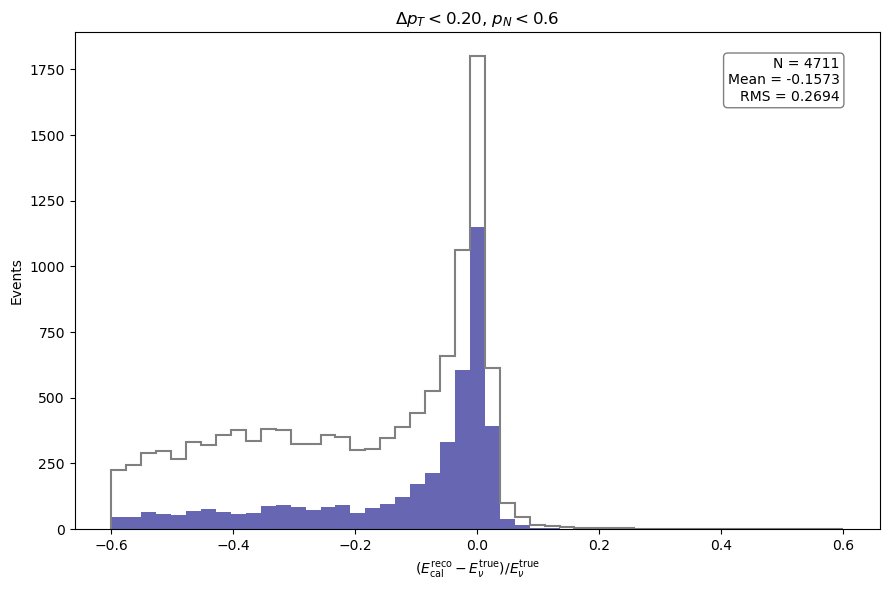

In [34]:
import numpy as np
import matplotlib.pyplot as plt


proton_mass = 0.938  # GeV
binding_energy = 0.03  # GeV

def compute_resolution_stats(df, label):
    reco_muon_energy = df["RecoMuonE_1muNp"]
    reco_proton_energy = df["RecoLeadProtonE_1muNp"]
    true_nu_energy = df["nu_e"]

    reco_ecal = reco_muon_energy + (reco_proton_energy - proton_mass) + binding_energy
    resolution = (reco_ecal - true_nu_energy) / true_nu_energy

    mean = resolution.mean()
    std = resolution.std()
    rms = np.sqrt((resolution ** 2).mean())
    stat_unc = std / np.sqrt(len(resolution))  # error on the mean

    print(f"{label}")
    print(f"  Events: {len(resolution)}")
    print(f"  Mean: {mean:.4f}, Std: {std:.4f}, RMS: {rms:.4f}, Stat. Unc.: {stat_unc:.4f}")
    return resolution, mean, std, rms, stat_unc

# All events 
res_all, mean_all, std_all, rms_all, staterr_all = compute_resolution_stats(sel_mc_1mu1p, r"All 1mu1p events")


# Selected slice 
#sel_sig['RecoAlpha3D_deg'] = np.rad2deg(sel_sig['RecoAlpha3D_1mu1p'])
sel_slice = sel_mc_1mu1p[
    (sel_mc_1mu1p["RecoDeltaPT_1mu1p"].values < 0.2)
    #& (sel_mc_1mu1p["RecoPN_1mu1p"].values < 0.22) 
     & (sel_mc_1mu1p["RecoDeltaAlphaT_1mu1p"].values < 2.5)   
]

res_cut, mean_cut, std_cut, rms_cut, staterr_cut = compute_resolution_stats(sel_slice, "pT < 0.2")


plt.figure(figsize=(9, 6))
bins = np.linspace(-0.6, 0.6, 50)

plt.hist(res_all, bins=bins, histtype='step', linewidth=1.5, label="All events", color="gray")
plt.hist(res_cut, bins=bins, histtype='stepfilled', alpha=0.6, label=r"$\Delta p_T < 0.20$", color="navy")

# Stats box for cut
stats_text_cut = (
    f"N = {len(res_cut)}\n"
    f"Mean = {mean_cut:.4f}\n"
    f"RMS = {rms_cut:.4f}"
    
)

plt.text(0.95, 0.95, stats_text_cut, transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize=10)


plt.title(r"$\Delta p_T < 0.20$, $p_N < 0.6$ ")
plt.xlabel(r"$(E_{\mathrm{cal}}^{\mathrm{reco}} - E_\nu^{\mathrm{true}})/E_\nu^{\mathrm{true}}$")
plt.ylabel("Events")
#plt.grid(True)
#plt.legend()
plt.tight_layout()
plt.savefig("ecal_pT_0.2_pN_0.6.pdf")
plt.show()
